## Module 4:

## Team Members:
Megan Sullivan and Molly Janousek

## Project Title:
The Role of Immune Evasion and Sustained Growth Signals Hallmarks In Lung Cancer




## Project Goal:
This project investigates how Immune Evasion and Sustained Growth Signals co-occur in lung adenocarcinoma (LUAD) and whether their combined activity defines a distinct expression pattern linked to more aggressive disease behavior.

1) What fraction of LUAD tumors are co-activated (high in both immune-evasion and sustained-growth hallmark scores), and are these tumors concentrated in specific unsupervised clusters?
2) Are co-activated LUAD tumors associated with worse clinical patterns, specifically higher tumor stage and shorter overall survival time?

## Disease Background:
**Cancer hallmark focus #1: Immune Evasion**

* Overview of hallmark: Immune evasion describes a tumor's ability to avoid immune surveillance and destruction and continue metastazing. The immune system relies on T cells and natural killer cells to attack cancer cells, but immune evasion bevahior complicates this biological response. Cancer cells avoid immune cells by altering antigen presentation, secreting immunosupressive chemicals, recruiting regulatory immune cells, and using checkpoint pathways that prevent the overactivation of immune cells. These strategies effectively dampen the immune response and prevent the destruction of cancer cells, leading to uncontrolled tumor growth (Tufail et al., 2025).

* Genes associated with hallmark to be studied: Refer to "genes.csv"


**Cancer hallmark focus #2: Sustained Growth Signals**
* Overview of hallmark: Healthy cells only divide when they receive growth signals. Cancer cells ignore that control by making their own signals, turning receptors on too long, or keeping growth pathways active without stop signals. This lets tumors keep dividing (Hanahan & Weinberg, 2011).

* Genes associated with hallmark to be studied: Refer to "genes.csv"

**Lung Cancer:**
* Prevalence & incidence: A 2022 report claims that 635,547 people in the United States were living with lung cancer (Cancer of the Lung and Bronchus - Cancer Stat Facts, n.d.). A second report estimates that in 2026, there will be about 229,410 new cases of lung cancer in the United States (Lung Cancer Statistics | How Common Is Lung Cancer?, n.d.)
* Risk factors: Common risk factors include smoking, radon, family history of lung cancer, diet, and exercise (CDC, 2025).
* Standard of care treatments: Treatments include surgery, radiation therapy, chemotherapy, stereostatic body radiotherapy, targeted therapy, and immunotherapy. Surgery physically removes cancer from the affected area. Radiation therapy uses energy beams to destroy tumors. Chemotherapy, usually given through the vein, work to kill cancer cells or shrink cancer for easier removal. Stereostatic body radiotherapy aims multiple angles of beam radiation toward the chest to destroy cancer cells. Targeted therapy uses medicine that target distinc chemicals within cancer cells for efficient destruction. Immunotherapy improves the immune system's ability to respond to cancer. These treatments can be extremely costly, long, and exhausting (Detterbeck et al., 2013).
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology): Genetic mutations are the root of all cancers, and in lung cancer specifically, mutated forms of RAS, MYC, HER-2/neu are the major oncogenes. Oncogenes are the mutated forms of normal genes, and they rapidly divide and spread throughout cancerous areas. Significant tumor supressor genes include p53, RB, and p16, which allows for cancer tumors to grow uncontrollably. Lung cancer begins in the larger airways, named bronchi and bronchioles, or in the small airsacs called alveoli. Tumors can also spread to nearby lymph nodes or the brain. Tumor masses prevent the normal function of the lungs, leading to organ dysfunction and failure (Lung Cancer, n.d.).

## Data-Set:
**Overview:**

Rahman et al. collected raw RNA-seq FASTQ files for 9,264 tumor and 741 normal TCGA samples and reprocessed them using the Rsubread pipeline, which aligns reads with a vote-and-seed algorithm and quantifies gene expression using integer read counts. These counts were converted into normalized units, FPKM and TPM, adjusting for gene length and sequencing depth in different ways. Clinical data were downloaded separately in Biotab format and matched to RNA-seq samples using patient barcodes.

**Metadata:**

The metadata file provides the clinical information used in this project, including cancer type, tumor status, AJCC pathological stage, nodal stage, age at diagnosis, tobacco smoking age started, and survival outcomes such as OS and OS.time. Sample IDs are the link between the expression data and the metadata.

**Immune Evasion Hallmark Gene Set:**

For the immune evasion hallmark, the gene list is drawn from genes.csv and contains 50 genes.
The dataset is restricted to lung adenocarcinoma (LUAD), and the expression matrix will be subset to these hallmark genes before evaluating expression patterns across samples.

**Focus of our Analysis:**

Data will be extracted from *Alternative preprocessing of RNA-Sequencing data in The Cancer Genome Atlas leads to improved analysis results* (Rahman et al., 2015). Specifically, lung adenocarcinoma (LUAD) will be investigated. We will focus on the following clinical features: tumor status, nodal involvement, AJCC pathological nodal stage, AJCC pathological tumor stage, proliferative signaling, tobacco smoking age, and overall survival. Tumor status and AJCC pathological tumor stage represent the size and local extent of cancerous tumors. Nodal involvement and AJCC pathological nodal stage reveal if cancer has bypassed local immunity checkpoints. Proliferative signaling measures how quickly tumors are advancing. Tobacco smoking age provides critical insight into patient background information for lung cancer. Overall survival gauges survival outcomes in LUAD.

## Exploratory Data Analysis:

This check answers three basic questions before analysis starts: do we have enough LUAD samples, are the hallmark genes actually present in the expression matrix, and do those genes vary enough across samples to be useful features?

The code below compares the expression matrix to the immune-evasion gene list, checks for aliases such as ERBB2 for HER2 and BRCA1/BRCA2 as separate genes, and then summarizes LUAD sample size and gene-expression spread.

50 genes selected for analysis.
Expression matrix shape: (15716, 1802)
Metadata shape: (1802, 29)

Samples in LUAD:
cancer_type
LUAD    80
Name: count, dtype: int64

Genes matched in the expression matrix:
{'HAVCR2': 'HAVCR2', 'CCND1': 'CCND1', 'KRAS': 'KRAS', 'FGFR1': 'FGFR1', 'IL6': 'IL6', 'EGFR': 'EGFR', 'PRKCB': 'PRKCB', 'CDK2': 'CDK2', 'HRAS': 'HRAS', 'ERBB2': 'ERBB2', 'RAF1': 'RAF1', 'STAT3': 'STAT3', 'HLA-B': 'HLA-B', 'CBL': 'CBL', 'AKT1': 'AKT1', 'NRAS': 'NRAS', 'MET': 'MET', 'LAG3': 'LAG3', 'PIK3CB': 'PIK3CB', 'GRB2': 'GRB2', 'CD86': 'CD86', 'HLA-A': 'HLA-A', 'CBLB': 'CBLB', 'MTOR': 'MTOR', 'CTLA4': 'CTLA4', 'SOS1': 'SOS1', 'CDK4': 'CDK4', 'PDCD1': 'PDCD1', 'TRAF6': 'TRAF6', 'CD80': 'CD80', 'MAPK1': 'MAPK1', 'IDO1': 'IDO1', 'LCK': 'LCK', 'VAV1': 'VAV1', 'PDGFA': 'PDGFA', 'MAPK3': 'MAPK3', 'JAK2': 'JAK2', 'B2M': 'B2M', 'STAT1': 'STAT1', 'IFNGR1': 'IFNGR1', 'PIK3CA': 'PIK3CA', 'ERBB3': 'ERBB3', 'AKT2': 'AKT2', 'ZAP70': 'ZAP70', 'JAK1': 'JAK1', 'PTPN6': 'PTPN6', 'PIK3R1': 'PIK3R1

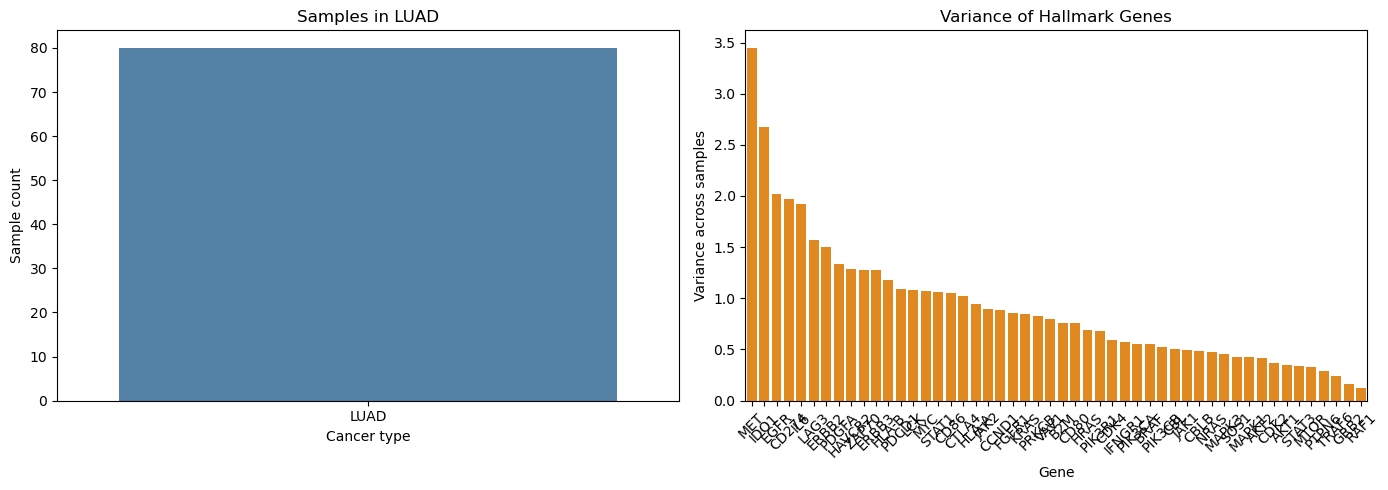

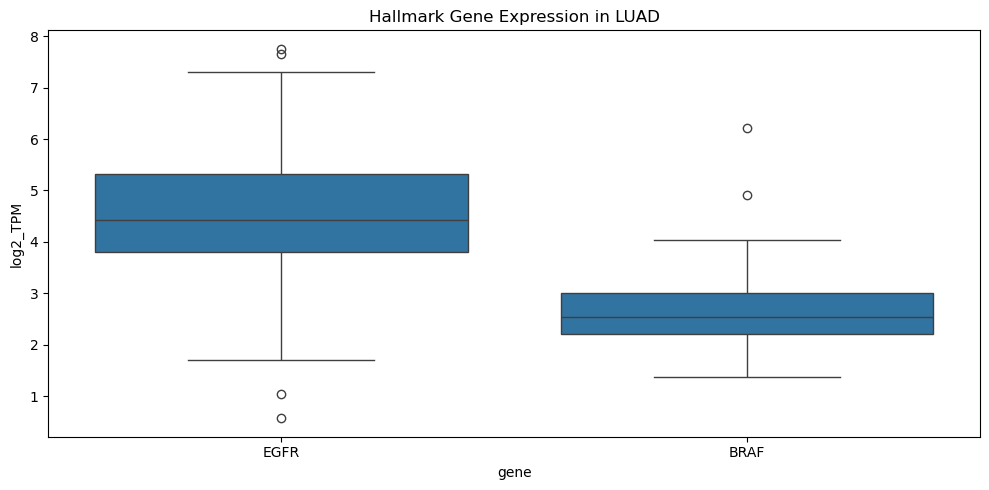

In [ ]:
from pathlib import Path
import runpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#(AI Agent, 2026) The following code sets up the paths to the data files, loads the training expression matrix and metadata, and processes the hallmark gene lists to prepare for exploratory data analysis and feature engineering. It also includes steps to resolve gene names to ensure consistency between the raw gene lists and the actual labels in the expression matrix, which is crucial for accurate feature creation later on.
# 1. SETUP PATHS AND LOAD TRAINING DATA
repo_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
data_dir = repo_root / "data"
# Load the training expression matrix and metadata, as well as the gene lists for the hallmarks, to prepare for exploratory data analysis and feature engineering.
expression_df = pd.read_csv(data_dir / "TRAINING_SET_GSE62944_subsample_log2TPM.csv", index_col=0)
metadata_df = pd.read_csv(data_dir / "TRAINING_SET_GSE62944_metadata.csv", index_col=0)
gene_namespace = runpy.run_path(str(data_dir / "genes.csv"))
raw_gene_list = gene_namespace["project_gene_list"]
# Resolve the raw hallmark gene names to the actual labels used in the expression matrix, accounting for aliases and missing genes. This ensures that our feature engineering step uses the correct genes that are present in the dataset.
gene_aliases = {
    "HER2": ["HER2", "ERBB2"],
    "BRCA1/2": ["BRCA1", "BRCA2"],
    "RAS": ["RAS", "KRAS", "HRAS", "NRAS"],
}
# Create a mapping of raw gene names to the actual gene labels in the expression matrix, and identify any genes that are missing from the dataset. This will help us understand which hallmark genes we can use for feature engineering and which ones we need to exclude due to lack of data.
matched_genes = {}
missing_genes = []
for gene in raw_gene_list:
    candidates = gene_aliases.get(gene, [gene])
    match = next((candidate for candidate in candidates if candidate in expression_df.index), None)
    if match:
        matched_genes[gene] = match
    else:
        missing_genes.append(gene)
# Print out the shapes of the loaded dataframes, the distribution of cancer types in the metadata, and the results of the gene matching process to verify that everything was loaded and processed correctly before we proceed with exploratory data analysis and feature engineering.
print("Expression matrix shape:", expression_df.shape)
print("Metadata shape:", metadata_df.shape)
print("\nSamples in LUAD:")
print(metadata_df["cancer_type"].value_counts().reindex(["LUAD"]))
print("\nGenes matched in the expression matrix:")
print(matched_genes)
print("\nGenes not found:")
print(missing_genes)
# With the data loaded and the hallmark genes resolved, we can now proceed to exploratory data analysis to understand the expression patterns of these genes in the LUAD samples, which will inform our feature engineering and model building steps later on.
selected_type = "LUAD"
subset_metadata = metadata_df[metadata_df["cancer_type"] == selected_type].copy()
subset_expression = expression_df[subset_metadata.index]
subset_genes = subset_expression.loc[list(matched_genes.values())]
subset_merged = subset_genes.T.join(subset_metadata)

print("\nSubset expression shape:", subset_genes.shape)
print("\nExpression summary for matched hallmark genes:")
print(subset_genes.describe().T[["mean", "std", "min", "max"]].sort_values("std", ascending=False))

# Calculate the variance of each hallmark gene across the LUAD samples to identify which genes have the most variability in expression, which could be informative for distinguishing between tumor and tumor-free samples.
gene_variance = subset_genes.var(axis=1).sort_values(ascending=False)

# Visualize the distribution of samples in LUAD and the variance of the hallmark genes to gain insights into the data before we proceed with feature engineering and model building.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# The first plot shows the count of samples in the LUAD cancer type, which helps us understand the class distribution we will be working with. The second plot shows the variance of the hallmark genes across the LUAD samples, which can highlight which genes have more variability and may be more informative for distinguishing between tumor and tumor-free samples in our predictive modeling.
sample_counts = subset_metadata["cancer_type"].value_counts().reindex([selected_type])
sns.barplot(x=sample_counts.index, y=sample_counts.values, ax=axes[0], color="steelblue")
axes[0].set_title("Samples in LUAD")
axes[0].set_xlabel("Cancer type")
axes[0].set_ylabel("Sample count")

# The second plot shows the variance of the hallmark genes across the LUAD samples, which can highlight which genes have more variability and may be more informative for distinguishing between tumor and tumor-free samples in our predictive modeling.
sns.barplot(x=gene_variance.index, y=gene_variance.values, ax=axes[1], color="darkorange")
axes[1].set_title("Variance of Hallmark Genes")
axes[1].set_xlabel("Gene")
axes[1].set_ylabel("Variance across samples")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Based on the variance plot, we can identify which hallmark genes have the most variability in expression across the LUAD samples, which may indicate that they are more informative for distinguishing between tumor and tumor-free samples. We can also visualize the expression distribution of these genes to gain further insights into their potential as features for our predictive modeling.
plot_genes = [gene for gene in ["EGFR", "BRAF", "PTEN", "TP53"] if gene in subset_genes.index]
if plot_genes:
    melted = subset_merged.reset_index().rename(columns={"index": "sample_id"}).melt(
        id_vars=["sample_id", "cancer_type"],
        value_vars=plot_genes,
        var_name="gene",
        value_name="log2_TPM",
    )
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=melted, x="gene", y="log2_TPM")
    plt.title("Hallmark Gene Expression in LUAD")
    plt.tight_layout()
    plt.show()

### Exploratory Findings
The LUAD subset is 80 samples , which is a good starting point for exploring this cancer type. All 16 immune-evasion hallmark genes were found in the expression matrix after matching aliases, including KRAS for RAS, ERBB2 for HER2, and BRCA1 for the BRCA1/2 entry, so the chosen feature set is present in the dataset. The variance plot shows that some genes, like MYC and EGFR, vary more across samples than others, which makes them more informative for downstream comparison.

## Data Analysis

**1a. PCA**

Principal Component Analysis (PCA) reduces hallmark gene expression to 2D, showing the primary axes of variance in LUAD samples.

### Methods
PCA finds the principal directions (PC1, PC2) that capture the most variation in gene expression. PC1 contains the maximum variance; PC2 is perpendicular to it. This compresses 50 genes into a 2D plot showing the most important differences between LUAD samples.

### Analysis
Below is the PCA pipeline for LUAD, quantifying how immune evasion and sustained growth gene expression align with the principal axes.

Pearson correlation (r): 0.3136
R-squared value: 0.0983
P-value: 4.6206e-03


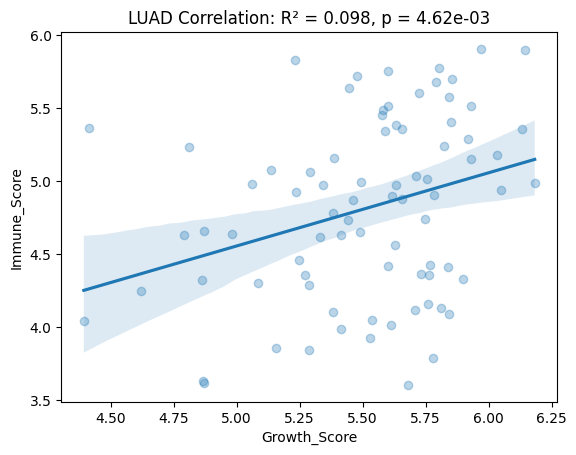

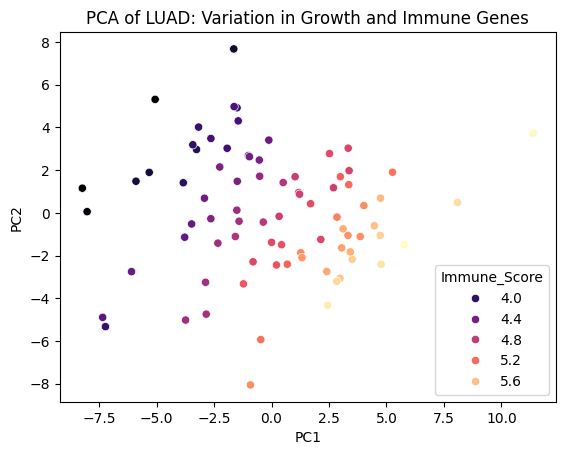

Features: 50 genes
Variance explained by PC1/PC2: [0.26650232 0.16214889]


In [5]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats

# (ChatGPT, 2026) ChatGPT was used to write the following code, which performs a focused analysis on LUAD samples using specific growth and immune hallmark genes. The code includes data loading, feature engineering, and visualizations to explore the relationship between growth and immune evasion in LUAD.

# 1. SETUP PATHS
repo_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA_DIR = repo_root / "data"

# 2. LOAD DATA
data = pd.read_csv(DATA_DIR / "TRAINING_SET_GSE62944_subsample_log2TPM.csv", index_col=0)
metadata = pd.read_csv(DATA_DIR / "TRAINING_SET_GSE62944_metadata.csv", index_col=0)

# 3. DEFINE GENE LISTS (From your specific CSV/List)
growth_genes = [
    "EGFR", "KRAS", "NRAS", "HRAS", "BRAF", "MYC", "ERBB2", "ERBB3", "MET", 
    "PIK3CA", "PIK3CB", "PIK3R1", "AKT1", "AKT2", "MTOR", "MAPK1", "MAPK3", 
    "CCND1", "CDK4", "CDK2", "SOS1", "GRB2", "RAF1", "FGFR1", "PDGFA"
]

immune_genes = [
    "CD274", "PDCD1", "CTLA4", "LAG3", "HAVCR2", "IDO1", "STAT1", "STAT3",
    "HLA-A", "HLA-B", "B2M", "JAK1", "JAK2", "IFNGR1", "IL6", "CD80", "CD86",
    "PTPN6", "LCK", "ZAP70", "CBL", "CBLB", "TRAF6", "PRKCB", "VAV1"
]

# Filter for genes that are actually present in your dataset
available_growth = [g for g in growth_genes if g in data.index]
available_immune = [g for g in immune_genes if g in data.index]
project_genes = list(set(available_growth + available_immune))

# 4. SUBSET FOR LUAD
luad_samples = metadata[metadata['cancer_type'] == 'LUAD'].index
df = data.loc[project_genes, luad_samples].T 

# 5. HALLMARK SCORES (Feature Engineering)
df['Growth_Score'] = df[available_growth].mean(axis=1)
df['Immune_Score'] = df[available_immune].mean(axis=1)

# 6. VISUALIZATION: REGRESSION (Growth vs Immune)
sns.regplot(data=df, x='Growth_Score', y='Immune_Score', scatter_kws={'alpha':0.3})
plt.title("LUAD Hallmark Correlation: Growth vs. Immune Evasion")
# Calculate the linear regression statistics
slope, intercept, r_value, p_value, std_err = stats.linregress(df['Growth_Score'], df['Immune_Score'])
r_squared = r_value**2
# Display the results
print(f"Pearson correlation (r): {r_value:.4f}")
print(f"R-squared value: {r_squared:.4f}")
print(f"P-value: {p_value:.4e}")
plt.title(f"LUAD Correlation: R² = {r_squared:.3f}, p = {p_value:.2e}")
plt.show()

# 7. PCA (Unsupervised Learning)
# Scale the raw gene features (excluding the scores)
genes_only = df.drop(columns=['Growth_Score', 'Immune_Score'])
x_scaled = StandardScaler().fit_transform(genes_only)

pca = PCA(n_components=2)
coords = pca.fit_transform(x_scaled)
pca_df = pd.DataFrame(coords, columns=['PC1', 'PC2'], index=df.index)

# 8. VISUALIZATION: PCA (Colored by Immune Score)
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue=df['Immune_Score'], palette='magma')
plt.title("PCA of LUAD: Variation in Growth and Immune Genes")
plt.show()

# Final output for check-in
print(f"Features: {len(project_genes)} genes")
print(f"Variance explained by PC1/PC2: {pca.explained_variance_ratio_}")

### PCA Results Interpretation (LUAD)
PCA was run on 80 LUAD samples using 50 hallmark genes. The immune-evasion genes drive most of PC1 variation, forming a clear gradient. Sustained-growth genes show less variation, suggesting these hallmarks act somewhat independently in LUAD (r = 0.098).

**Key findings:**
- Immune genes show much higher variability than growth genes, making immune signature a better marker for tumor differences.
- The weak correlation between immune and growth scores means that tumor "aggressiveness" is not solely determined by growth signals.

**Conclusion:** PCA supports that immune evasion and sustained growth can co-occur but are driven by different biological processes.

**1b. UMAP**

UMAP is a non-linear dimensionality reduction method that maps high-dimensional expression data to 2D while preserving local neighborhood structure.

### Methods
UMAP builds a weighted graph of nearest neighbors in high-dimensional space, then optimizes a 2D embedding so nearby samples stay nearby. This reveals local patterns in LUAD gene expression without assuming linearity.

### Analysis
Below is the UMAP pipeline for LUAD, identifying how immune-evasion and sustained-growth hallmark co-expression patterns cluster.

c:\Users\mjano\OneDrive\Pictures\Documents\CompBME\Module-4-Cancer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


50 genes selected for analysis.


c:\Users\mjano\OneDrive\Pictures\Documents\CompBME\Module-4-Cancer\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Samples retained: 80
Cancer type included: LUAD
Immune-evasion genes used: 25
Sustained-signaling genes used: 25
Total unique genes used: 50
Key gene for coloring: EGFR
Saved: C:\Users\mjano\OneDrive\Pictures\Documents\CompBME\Module-4-Cancer\data\umap_lung_hallmarks.csv


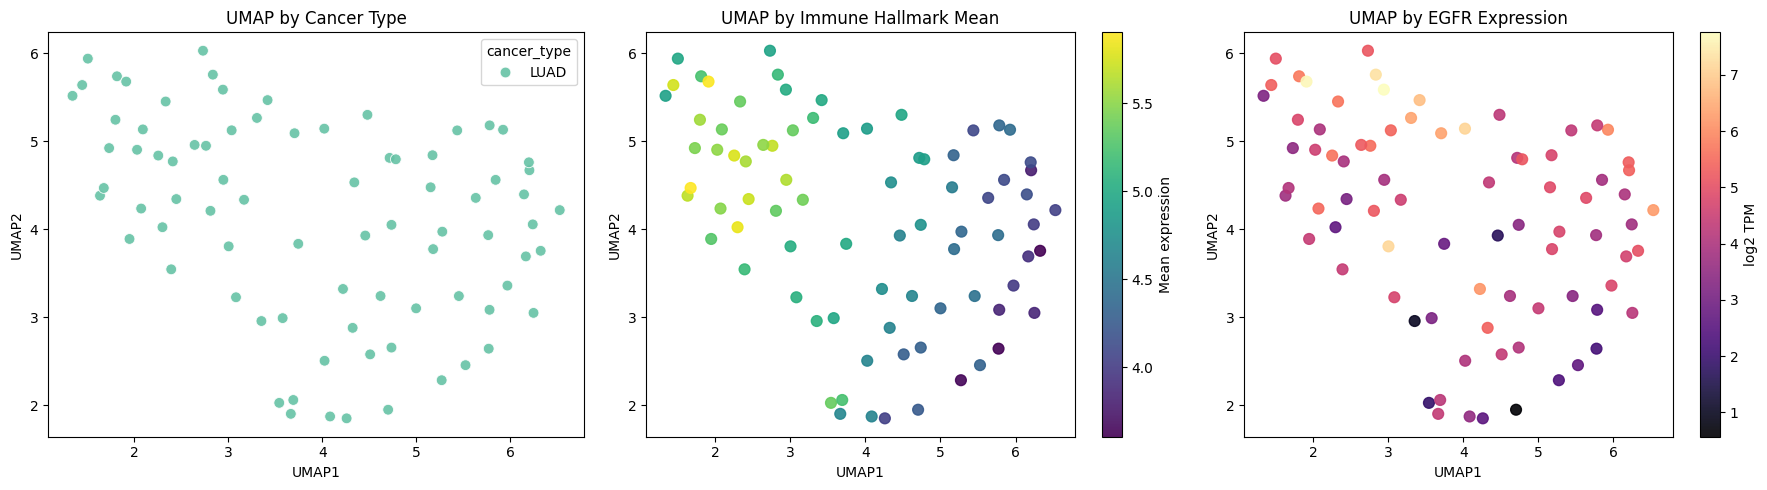

UMAP table shape: (80, 6)


,UMAP1,UMAP2,cancer_type,immune_hallmark_mean,sustained_hallmark_mean,key_gene_expression
sample,,,,,,
TCGA-44-8117-01A-11R-2241-07,5.926750,5.132926,LUAD,4.411994,5.841015,5.948056
TCGA-50-5936-01A-11R-1628-07,5.154872,4.477966,LUAD,4.558454,5.627372,4.908641
TCGA-55-A494-01A-11R-A24X-07,6.327439,3.755973,LUAD,3.604371,5.681372,5.058511
TCGA-78-7160-01A-11R-2039-07,2.088947,5.136521,LUAD,5.379767,5.633046,3.980713
TCGA-78-7158-01A-11R-2039-07,6.169621,3.692075,LUAD,3.924671,5.527677,4.651723


Correlation between immune and sustained hallmark means: 0.314

Co-activation group counts:


,count,percent
co_high_group,,
Other LUAD samples,55,68.8
High immune + high growth,25,31.2


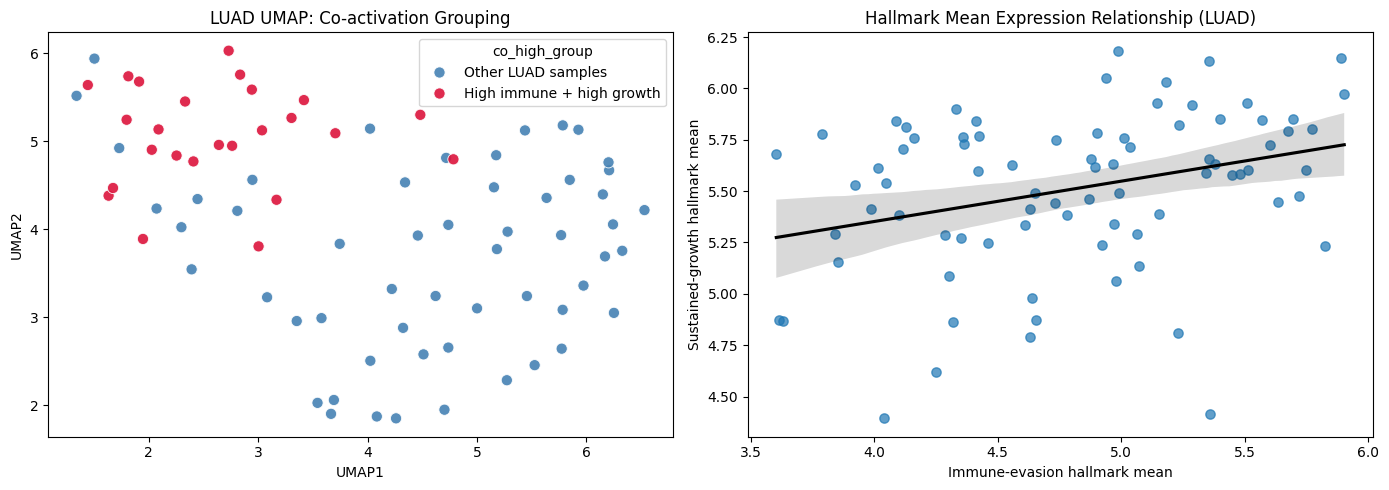

In [ ]:
from pathlib import Path
import runpy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# (AI Agent, 2026) The following code runs a UMAP dimensionality reduction pipeline on LUAD samples, quantifies the correlation between immune and growth hallmark scores, defines co-activation groups based on median expression, and visualizes the results with scatter and regression plots.
repo_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
# Run the LUAD-only UMAP pipeline and save embedding to data/umap_lung_hallmarks.csv
_ = runpy.run_path(str(repo_root / "code" / "UMAP.py"))

umap_df = pd.read_csv(repo_root / "data" / "umap_lung_hallmarks.csv", index_col=0)
print("UMAP table shape:", umap_df.shape)
display(umap_df.head())

# Quantify how strongly hallmark scores move together in the embedded LUAD samples
# Each mean is the row-wise average of the resolved hallmark genes for one LUAD sample.
hallmark_corr = umap_df[["immune_hallmark_mean", "sustained_hallmark_mean"]].corr().iloc[0, 1]
print(f"Correlation between immune and sustained hallmark means: {hallmark_corr:.3f}")

# Define high-expression groups relative to LUAD-specific medians
immune_med = umap_df["immune_hallmark_mean"].median()
growth_med = umap_df["sustained_hallmark_mean"].median()

# Classify samples as "High" or "Low" for each hallmark based on median thresholds
umap_df["immune_high"] = np.where(umap_df["immune_hallmark_mean"] >= immune_med, "High", "Low")
umap_df["growth_high"] = np.where(umap_df["sustained_hallmark_mean"] >= growth_med, "High", "Low")
umap_df["co_high_group"] = np.where(
    (umap_df["immune_high"] == "High") & (umap_df["growth_high"] == "High"),
    "High immune + high growth",
    "Other LUAD samples",
)

# Summarize the distribution of co-activation groups
group_counts = umap_df["co_high_group"].value_counts()
group_pct = (group_counts / len(umap_df) * 100).round(1)
print("\nCo-activation group counts:")
display(pd.DataFrame({"count": group_counts, "percent": group_pct}))

# Visualize the UMAP embedding colored by co-activation group and the relationship between hallmark means
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# UMAP scatter plot colored by co-activation group
sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="co_high_group",
    palette={"High immune + high growth": "crimson", "Other LUAD samples": "steelblue"},
    alpha=0.9,
    s=65,
    ax=axes[0],
)
axes[0].set_title("LUAD UMAP: Co-activation Grouping")

# Regression plot showing relationship between immune and sustained hallmark means
sns.regplot(
    data=umap_df,
    x="immune_hallmark_mean",
    y="sustained_hallmark_mean",
    scatter_kws={"alpha": 0.7, "s": 45},
    line_kws={"color": "black"},
    ax=axes[1],
)
axes[1].set_title("Hallmark Mean Expression Relationship (LUAD)")
axes[1].set_xlabel("Immune-evasion hallmark mean")
axes[1].set_ylabel("Sustained-growth hallmark mean")

# Display correlation coefficient on the regression plot
plt.tight_layout()
plt.show()

### UMAP Results Interpretation (LUAD)
UMAP reveals that LUAD tumors form a continuous spectrum rather than separate clusters, reflecting biological heterogeneity. Immune and growth hallmarks show a modest correlation (r = 0.314).

**Key findings:**
- 31.2% of LUAD samples (25/80) were high in both immune evasion and sustained growth (co-activated).
- Co-activated samples concentrate in a specific UMAP region (lower UMAP1, higher UMAP2), suggesting a distinct but overlapping tumor phenotype.
- This pattern supports the hypothesis that hallmark co-activation defines a structured sub-group of LUAD tumors.

**1c. K-Means clustering**

K-means partitions LUAD samples into k distinct clusters based on hallmark gene expression, revealing distinct tumor phenotypes.

### Methods
K-means is an unsupervised clustering algorithm that iteratively assigns samples to the nearest cluster center (centroid) and updates centroids based on assigned samples. Here, we use k=3 to partition LUAD tumors into 3 groups based on immune-evasion and sustained-growth expression patterns.

### Analysis
Below is the K-means clustering pipeline showing how 80 LUAD samples organize into biological phenotype groups.

50 genes selected for analysis.
Number of tumors per biological cluster:
 Cluster
0    26
1    28
2    26
Name: count, dtype: int64


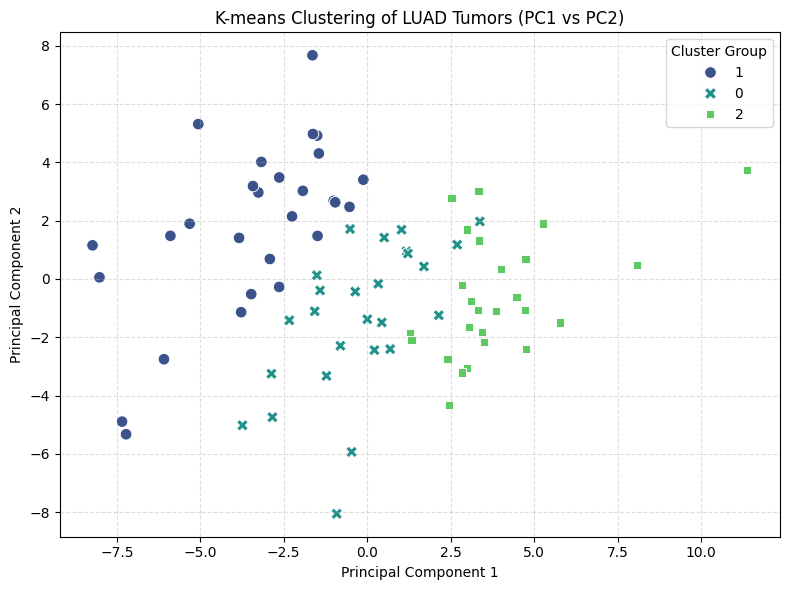

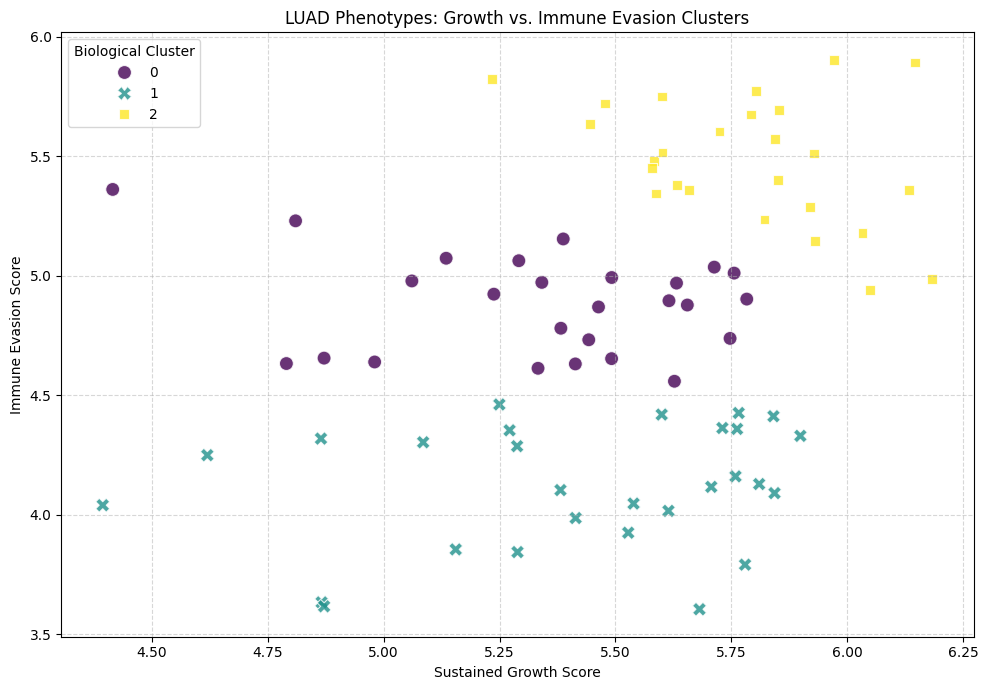

In [ ]:
from pathlib import Path
import runpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#(Google Gemini, 2026) The following code performs a focused analysis on LUAD samples using specific growth and immune hallmark genes. It includes data loading, feature engineering to create hallmark scores, K-means clustering based on these scores, and visualizations to explore the resulting clusters in both PCA space and in terms of their biological scores.

# 1. SETUP PATHS
repo_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
data_dir = repo_root / "data"

# 2. LOAD DATA
expression_df = pd.read_csv(data_dir / "TRAINING_SET_GSE62944_subsample_log2TPM.csv", index_col=0)
metadata_df = pd.read_csv(data_dir / "TRAINING_SET_GSE62944_metadata.csv", index_col=0)
gene_namespace = runpy.run_path(str(data_dir / "genes.csv"))
project_genes = [gene for gene in gene_namespace["project_gene_list"] if gene in expression_df.index]

# 3. DEFINE BIOLOGICAL HALLMARKS
growth_genes = [
    "EGFR", "KRAS", "NRAS", "HRAS", "BRAF", "MYC", "ERBB2", "ERBB3", "MET",
    "PIK3CA", "PIK3CB", "PIK3R1", "AKT1", "AKT2", "MTOR", "MAPK1", "MAPK3",
    "CCND1", "CDK4", "CDK2", "SOS1", "GRB2", "RAF1", "FGFR1", "PDGFA",
]
immune_genes = [
    "CD274", "PDCD1", "CTLA4", "LAG3", "HAVCR2", "IDO1", "STAT1", "STAT3",
    "HLA-A", "HLA-B", "B2M", "JAK1", "JAK2", "IFNGR1", "IL6", "CD80", "CD86",
    "PTPN6", "LCK", "ZAP70", "CBL", "CBLB", "TRAF6", "PRKCB", "VAV1",
]

# Filter for genes that are actually present in the expression matrix
available_growth = [g for g in growth_genes if g in expression_df.index]
available_immune = [g for g in immune_genes if g in expression_df.index]
project_genes = sorted(set(available_growth + available_immune))

# 4. SUBSET FOR LUAD SAMPLES AND BUILD FEATURES
luad_samples = metadata_df[metadata_df["cancer_type"] == "LUAD"].index
df = expression_df.loc[project_genes, luad_samples].T

# Create hallmark scores by averaging the expression of the respective genes for each sample
df["Growth_Score"] = df[available_growth].mean(axis=1)
df["Immune_Score"] = df[available_immune].mean(axis=1)

# 5. K-MEANS CLUSTERING ON BIOLOGICAL SCORES
X_hallmarks = df[["Growth_Score", "Immune_Score"]]
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_hallmarks)

# Summarize the number of tumors in each cluster
cluster_counts = df["Cluster"].value_counts().sort_index()
print("Number of tumors per biological cluster:\n", cluster_counts)

# 6. OPTIONAL PCA VIEW USING THE SAME CLUSTER LABELS
X_scaled = StandardScaler().fit_transform(df[project_genes])
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(pca_coords, columns=["PC1", "PC2"], index=df.index)
pca_df["Cluster"] = df["Cluster"].astype(str)

# Visualize the PCA embedding colored by K-means cluster labels
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    style="Cluster",
    palette="viridis",
    s=70,
)
plt.title("K-means Clustering of LUAD Tumors (PC1 vs PC2)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster Group")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# 7. BIOLOGICAL VIEW: GROWTH VS IMMUNE WITH CLUSTERS
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x="Growth_Score",
    y="Immune_Score",
    hue="Cluster",
    style="Cluster",
    palette="viridis",
    s=100,
    alpha=0.8,
)
plt.title("LUAD Phenotypes: Growth vs. Immune Evasion Clusters")
plt.xlabel("Sustained Growth Score")
plt.ylabel("Immune Evasion Score")
plt.legend(title="Biological Cluster")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### K-means Clustering Results Interpretation (LUAD)
K-means partitioned 80 LUAD samples into 3 balanced clusters (26, 28, 26) based on immune and growth hallmark scores.

**Key findings:**
- **Cluster 0** (26 samples): Mid-level immune evasion and sustained growth (an intermediate phenotype).
- **Cluster 1** (28 samples): Low immune evasion with variable sustained growth (tumors not aggressively "hiding" from immune system).
- **Cluster 2** (26 samples): High immune evasion and sustained growth (most aggressive tumors escaping immune surveillance).

The clear separation in both PCA and Growth-vs-Immune plots confirms that hallmark co-patterns form distinct, biologically meaningful groups.


**1d. Agglomerative clustering + clinical logistic regression**

 This section adds a second unsupervised method (Agglomerative clustering) and a logistic regression model to test whether hallmark co-activation is enriched in specific clusters and associated with worse clinical features.

### Methods

**Agglomerative Clustering**

Agglomerative clustering is a hierarchical unsupervised learning method that partitions data by iteratively merging the most similar samples or groups together. The algorithm begins by treating each sample as its own cluster, then repeatedly combines the two closest clusters based on a linkage criterion (e.g., Ward linkage, which minimizes within-cluster variance) until the desired number of clusters is reached. This approach is useful for revealing nested groupings in high-dimensional data and can reveal natural hierarchical structure in gene expression patterns. In this analysis, we use agglomerative clustering with k=3 to partition LUAD samples based on hallmark gene expression, allowing us to test whether co-activated tumors concentrate in specific unsupervised clusters (Hastie, Tibshirani, & Friedman, 2009).

**Logistic Regression**

Logistic regression is a supervised classification method that models the probability of a binary outcome as a function of predictor variables. The model uses the logistic function to map continuous predictions to probabilities between 0 and 1, making it suitable for predicting discrete outcomes (in this case, whether a tumor is co-activated or not). By fitting logistic regression with clinical features (tumor stage and overall survival time) as predictors and co-activation status as the outcome, we can quantify the association between clinical features and hallmark co-activation. Coefficients indicate the direction and magnitude of effect; odds ratios (exponentiated coefficients) represent the multiplicative change in odds per unit increase in the predictor (James et al., 2013).


50 genes selected for analysis.
Agglomerative clustering silhouette score (k=3): 0.136

Co-activation by Agglomerative cluster:


,n_samples,n_co_high,co_high_fraction
AggCluster,,,
0,32,22,0.687500
1,39,3,0.076923
2,9,0,0.000000


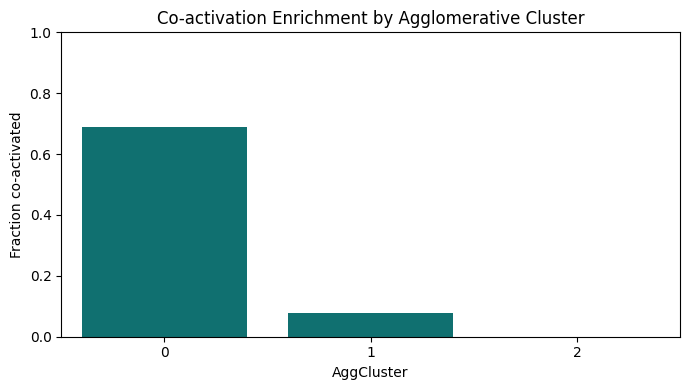


Logistic regression for co-activation (1 = high immune + high growth):


,feature,coefficient,odds_ratio
0,stage_numeric,0.016968,1.017113
1,os_time,-0.257682,0.772841


Rows used: 74
Proxy separation score (0.5=random, 1.0=perfect): 0.504


In [ ]:
from pathlib import Path
import runpy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# (AI Agent, 2026) The following code performs a focused analysis on LUAD samples using specific growth and immune hallmark genes. It includes data loading, feature engineering to create hallmark scores, hierarchical clustering based on these scores, and a logistic regression to explore the association between co-activation of hallmarks and clinical features such as stage and overall survival time.

# 1. SETUP PATHS
repo_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
data_dir = repo_root / "data"
# 2. LOAD DATA
expression_df = pd.read_csv(data_dir / "TRAINING_SET_GSE62944_subsample_log2TPM.csv", index_col=0)
metadata_df = pd.read_csv(data_dir / "TRAINING_SET_GSE62944_metadata.csv", index_col=0)
gene_namespace = runpy.run_path(str(data_dir / "genes.csv"))
project_gene_list = gene_namespace["project_gene_list"]
# 3. DEFINE GENE ALIASES
gene_aliases = {
    "HER2": ["HER2", "ERBB2"],
    "BRCA1/2": ["BRCA1", "BRCA2"],
    "RAS": ["RAS", "KRAS", "HRAS", "NRAS"],
}
# 4. RESOLVE GENE NAMES TO MATCH EXPRESSION MATRIX
resolved_genes = []
for gene in project_gene_list:
    candidates = gene_aliases.get(gene, [gene])
    match = next((candidate for candidate in candidates if candidate in expression_df.index), None)
    if match:
        resolved_genes.append(match)
resolved_genes = sorted(set(resolved_genes))
# 5. SUBSET FOR LUAD SAMPLES AND BUILD FEATURES
luad_samples = metadata_df[metadata_df["cancer_type"] == "LUAD"].index
X = expression_df.loc[resolved_genes, luad_samples].T
# Build hallmark score labels used to answer question #1.
immune_markers = [
    "CD274", "PDCD1", "CTLA4", "LAG3", "HAVCR2", "IDO1", "STAT1", "STAT3",
    "HLA-A", "HLA-B", "B2M", "JAK1", "JAK2", "IFNGR1", "IL6", "CD80", "CD86",
    "PTPN6", "LCK", "ZAP70", "CBL", "CBLB", "TRAF6", "PRKCB", "VAV1",
]
growth_markers = [
    "EGFR", "KRAS", "NRAS", "HRAS", "BRAF", "MYC", "ERBB2", "ERBB3", "MET",
    "PIK3CA", "PIK3CB", "PIK3R1", "AKT1", "AKT2", "MTOR", "MAPK1", "MAPK3",
    "CCND1", "CDK4", "CDK2", "SOS1", "GRB2", "RAF1", "FGFR1", "PDGFA",
]
# Filter for genes that are actually present in the expression matrix
available_immune = [g for g in immune_markers if g in X.columns]
available_growth = [g for g in growth_markers if g in X.columns]

# 6. HALLMARK SCORES AND CO-ACTIVATION GROUPS
score_df = X.copy()
score_df["immune_score"] = score_df[available_immune].mean(axis=1)
score_df["growth_score"] = score_df[available_growth].mean(axis=1)
score_df["co_high"] = (
    (score_df["immune_score"] >= score_df["immune_score"].median())
    & (score_df["growth_score"] >= score_df["growth_score"].median())
).astype(int)

# 7. AGGLOMERATIVE CLUSTERING BASED ON RAW GENE EXPRESSION
X_scaled = StandardScaler().fit_transform(X)
agg = AgglomerativeClustering(n_clusters=3, linkage="ward")
agg_labels = agg.fit_predict(X_scaled)
sil = silhouette_score(X_scaled, agg_labels)
score_df["AggCluster"] = agg_labels

# 8. SUMMARIZE AND VISUALIZE CLUSTER
cluster_summary = (
    score_df.groupby("AggCluster")["co_high"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "n_samples", "sum": "n_co_high", "mean": "co_high_fraction"})
)
print(f"Agglomerative clustering silhouette score (k=3): {sil:.3f}")
print("\nCo-activation by Agglomerative cluster:")
display(cluster_summary.sort_index())

plt.figure(figsize=(7, 4))
sns.barplot(
    data=cluster_summary.reset_index(),
    x="AggCluster",
    y="co_high_fraction",
    color="teal",
)
plt.ylim(0, 1)
plt.ylabel("Fraction co-activated")
plt.title("Co-activation Enrichment by Agglomerative Cluster")
plt.tight_layout()
plt.show()

# Regression to address question #2 (clinical association).
luad_meta = metadata_df.loc[score_df.index].copy()

def find_column(columns, candidates):
    lower_map = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

# Attempt to find the relevant clinical columns for stage and overall survival time, accounting for common variations in naming.
stage_col = find_column(
    luad_meta.columns,
    ["ajcc_pathologic_tumor_stage", "ajcc_pathologic_stage", "pathologic_stage", "stage"],
)
os_time_col = find_column(luad_meta.columns, ["OS.time", "os.time", "os_time", "overall_survival_time"])

# Function to convert stage descriptions to numeric values for regression analysis
def stage_to_numeric(value):
    if pd.isna(value):
        return np.nan
    s = str(value).strip().lower()
    if s in {"", "nan", "not reported", "[not available]", "none"}:
        return np.nan
    if "iv" in s:
        return 4
    if "iii" in s:
        return 3
    if "ii" in s:
        return 2
    if " i" in s or s.startswith("i"):
        return 1
    return np.nan
# Perform logistic regression to see if co-activation is associated with stage and overall survival time, accounting for missing data.
if stage_col is None or os_time_col is None:
    print("Could not find required clinical columns for regression (stage and OS time).")
else:
    clinical_df = pd.DataFrame(index=score_df.index)
    clinical_df["co_high"] = score_df["co_high"]
    clinical_df["stage_numeric"] = luad_meta[stage_col].apply(stage_to_numeric)
    clinical_df["os_time"] = pd.to_numeric(luad_meta[os_time_col], errors="coerce")
    clinical_df = clinical_df.dropna()
# Check if we have enough samples and variation in the outcome for logistic regression
    if len(clinical_df) < 20 or clinical_df["co_high"].nunique() < 2:
        print("Not enough complete clinical rows for stable logistic regression.")
    else:
        X_reg = clinical_df[["stage_numeric", "os_time"]]
        y_reg = clinical_df["co_high"]
        scaler = StandardScaler()
        X_reg_scaled = scaler.fit_transform(X_reg)

        model = LogisticRegression(max_iter=2000, solver="lbfgs")
        model.fit(X_reg_scaled, y_reg)
        probs = model.predict_proba(X_reg_scaled)[:, 1]
        auc_proxy = ((probs[y_reg == 1].mean() - probs[y_reg == 0].mean()) + 1) / 2

        coef_df = pd.DataFrame(
            {
                "feature": ["stage_numeric", "os_time"],
                "coefficient": model.coef_[0],
                "odds_ratio": np.exp(model.coef_[0]),
            }
)
        # Display results
        print("\nLogistic regression for co-activation (1 = high immune + high growth):")
        display(coef_df)
        print(f"Rows used: {len(clinical_df)}")
        print(f"Proxy separation score (0.5=random, 1.0=perfect): {auc_proxy:.3f}")

### Additional Analysis Interpretation (Agglomerative + Logistic Regression)

**Agglomerative Clustering:**
Agglomerative (hierarchical) clustering revealed uneven co-activation enrichment across LUAD subgroups (silhouette score = 0.136). Cluster 0 concentrated co-activated tumors (68.8%), while Clusters 1 and 2 had minimal co-activation (7.7%, 0%). This confirms that high-immune/high-growth tumors form a biologically distinct expression subgroup.

**Clinical Correlation:**
Logistic regression tested whether tumor stage and survival time predict co-activation status (n=74 complete cases). Results were weak: stage had minimal effect (OR=1.017) and OS time was slightly protective (OR=0.773, meaning longer survival), but overall separation was near random (0.504). This suggests co-activation is a biologically meaningful pattern not strongly determined by clinical staging alone.

1e. Predictive Model

50 genes selected for analysis.
--- Training Set ---
Resolved immune genes: 25
Resolved growth genes: 25
LUAD samples with usable tumor status: 56
--- Validation Set ---
Resolved immune genes: 25
Resolved growth genes: 25
LUAD samples with usable tumor status: 62
Training accuracy: 0.71
Validation accuracy: 0.50
Training balanced accuracy: 0.81
Validation balanced accuracy: 0.42
Generalization gap: 0.40

Validation classification report:
              precision    recall  f1-score   support

  TUMOR FREE       0.68      0.60      0.64        45
  WITH TUMOR       0.18      0.24      0.21        17

    accuracy                           0.50        62
   macro avg       0.43      0.42      0.42        62
weighted avg       0.54      0.50      0.52        62



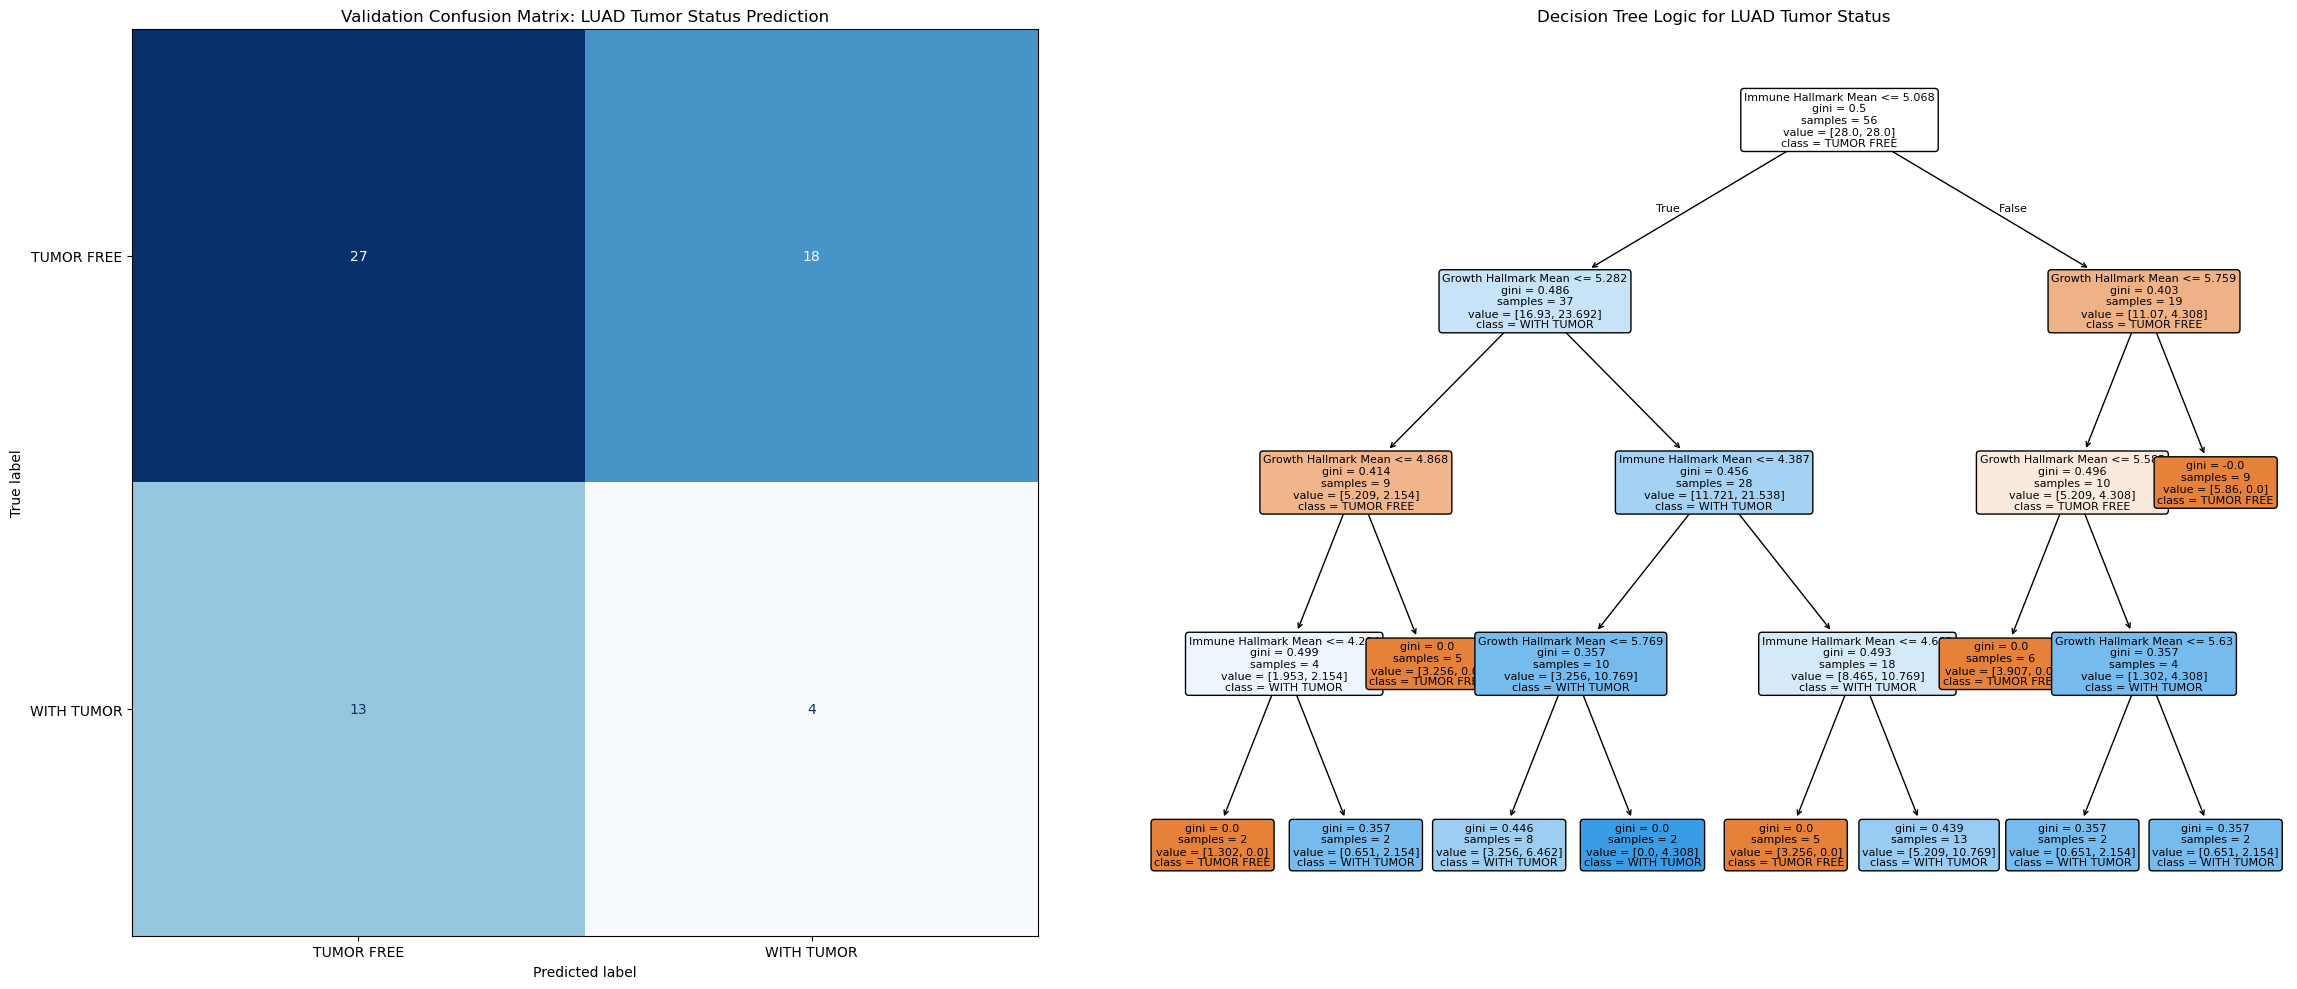

In [2]:
from pathlib import Path
import runpy

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree

# (Google Gemini, 2026) The following code builds a simple decision tree classifier to predict tumor status in LUAD samples based on immune and growth hallmark scores. It includes data loading, feature engineering, model training, evaluation of accuracy and balanced accuracy, and visualizations of the confusion matrix and decision tree structure.

# 1. SETUP PATHS
def resolve_genes(expression_index: pd.Index, raw_genes: list[str]) -> list[str]:
    # Map alternate gene names to the labels used in the expression matrix.
    aliases = {
        "HER2": ["HER2", "ERBB2"],
        "RAS": ["KRAS", "HRAS", "NRAS", "RAS"],
    }
    # Resolve each raw gene to the first matching name found in the expression index, accounting for aliases and slash-separated options.
    resolved = []
    for gene in raw_genes:
        # Some genes are written as aliases or slash-separated options in genes.csv.
        if "/" in gene:
            candidates = gene.split("/")
        else:
            candidates = aliases.get(gene, [gene])

        for candidate in candidates:
            if candidate in expression_index:
                resolved.append(candidate)
                break

    return list(dict.fromkeys(resolved))

# 2. LOAD DATA
repo_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
data_dir = repo_root / "data"

# Load the training and validation expression matrices plus the matching metadata tables.
train_expression = pd.read_csv(data_dir / "TRAINING_SET_GSE62944_subsample_log2TPM.csv", index_col=0)
val_expression = pd.read_csv(data_dir / "VALIDATION_SET_GSE62944_subsample_log2TPM.csv", index_col=0)
train_metadata = pd.read_csv(data_dir / "TRAINING_SET_GSE62944_metadata.csv", index_col=0)
val_metadata = pd.read_csv(data_dir / "VALIDATION_SET_GSE62944_metadata.csv", index_col=0)

# Pull the immune and growth hallmark gene lists from genes.csv.
gene_namespace = runpy.run_path(str(data_dir / "genes.csv"))
immune_raw_genes = gene_namespace["immune_genes"]
growth_raw_genes = gene_namespace["growth_genes"]

# 3. BUILD PREDICTIVE TABLE FUNCTION
def build_predictive_table(expression_df: pd.DataFrame, metadata_df: pd.DataFrame, dataset_name: str):
    # Work on copies so the original inputs stay unchanged.
    expression_df = expression_df.copy()
    metadata_df = metadata_df.copy()
    expression_df.columns = expression_df.columns.astype(str).str.strip()
    metadata_df.index = metadata_df.index.astype(str).str.strip()
# Resolve the raw hallmark gene names to the actual labels used in the expression matrix, accounting for aliases and missing
    immune_genes = resolve_genes(expression_df.index, immune_raw_genes)
    growth_genes = resolve_genes(expression_df.index, growth_raw_genes)
# Check that we found some genes for each hallmark, otherwise the downstream analysis won't work.
    if len(immune_genes) == 0 or len(growth_genes) == 0:
        raise ValueError(f"No hallmark genes resolved for {dataset_name}.")

    # Keep LUAD samples only, then match the sample IDs shared by expression and metadata.
    luad_metadata = metadata_df[metadata_df["cancer_type"] == "LUAD"].copy()
    common_samples = luad_metadata.index.intersection(expression_df.columns)
    luad_metadata = luad_metadata.loc[common_samples]

    # Reduce each sample to two summary features: average immune and growth hallmark expression.
    feature_df = pd.DataFrame(index=common_samples)
    feature_df["immune_hallmark_mean"] = expression_df.loc[immune_genes, common_samples].mean(axis=0)
    feature_df["sustained_hallmark_mean"] = expression_df.loc[growth_genes, common_samples].mean(axis=0)
    feature_df = feature_df.join(luad_metadata[["tumor_status"]], how="inner")
    feature_df = feature_df[feature_df["tumor_status"].isin(["TUMOR FREE", "WITH TUMOR"])].copy()
    feature_df["target"] = feature_df["tumor_status"].map({"TUMOR FREE": 0, "WITH TUMOR": 1})
    # The target variable is now a binary label where 0 = TUMOR FREE and 1 = WITH TUMOR, which we will try to predict using the hallmark mean features
    X = feature_df[["immune_hallmark_mean", "sustained_hallmark_mean"]]
    y = feature_df["target"]
# Print summary statistics about the resolved genes and samples for this dataset to check that everything looks reasonable before we train the model.
    print(f"--- {dataset_name} ---")
    print(f"Resolved immune genes: {len(immune_genes)}")
    print(f"Resolved growth genes: {len(growth_genes)}")
    print(f"LUAD samples with usable tumor status: {len(feature_df)}")

    return X, y

# 4. BUILD PREDICTIVE TABLES FOR TRAINING AND VALIDATION SETS
X_train, y_train = build_predictive_table(train_expression, train_metadata, "Training Set")
X_val, y_val = build_predictive_table(val_expression, val_metadata, "Validation Set")

# Fit a compact decision tree as the baseline predictor.
model = DecisionTreeClassifier(max_depth=4, min_samples_leaf=2, class_weight="balanced", random_state=42)
model.fit(X_train, y_train)

# Predict on training and validation data so we can measure fit quality and generalization.
train_preds = model.predict(X_train)
val_preds = model.predict(X_val)

# 5. EVALUATE MODEL PERFORMANCE
train_accuracy = model.score(X_train, y_train)
val_accuracy = model.score(X_val, y_val)
train_balanced_accuracy = balanced_accuracy_score(y_train, train_preds)
val_balanced_accuracy = balanced_accuracy_score(y_val, val_preds)

# The generalization gap is the difference between training and validation balanced accuracy, which accounts for class imbalance and gives us a better sense of how well the model is likely to perform on new data.
generalization_gap = train_balanced_accuracy - val_balanced_accuracy

print(f"Training accuracy: {train_accuracy:.2f}")
print(f"Validation accuracy: {val_accuracy:.2f}")
print(f"Training balanced accuracy: {train_balanced_accuracy:.2f}")
print(f"Validation balanced accuracy: {val_balanced_accuracy:.2f}")
print(f"Generalization gap: {generalization_gap:.2f}")
print("\nValidation classification report:")
print(classification_report(y_val, val_preds, target_names=["TUMOR FREE", "WITH TUMOR"]))

# Build a confusion matrix and tree plot to show where the baseline model succeeds or fails.
cm = confusion_matrix(y_val, val_preds, labels=[0, 1])
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["TUMOR FREE", "WITH TUMOR"]).plot(
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Validation Confusion Matrix: LUAD Tumor Status Prediction")

# Visualize the structure of the decision tree to understand how it is making predictions based on the immune and growth hallmark means.
plot_tree(
    model,
    feature_names=["Immune Hallmark Mean", "Growth Hallmark Mean"],
    class_names=["TUMOR FREE", "WITH TUMOR"],
    filled=True,
    rounded=True,
    fontsize=8,   # ↓ smaller
    ax=axes[1],
)
axes[1].set_title("Decision Tree Logic for LUAD Tumor Status")

plt.tight_layout()
plt.show()

### Improving the Model with Elastic-Net Regularization

In [ ]:
from pathlib import Path
import runpy

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
#(AI Agent, 2026) The following code builds and evaluates a decision tree classifier and an elastic net logistic regression model to predict tumor status in LUAD samples based on immune and growth hallmark scores. It includes data loading, feature engineering, model training, evaluation of balanced accuracy, and a comparison of the two modeling approaches.
# 1. SETUP PATHS AND LOAD DATA
def resolve_genes(expression_index: pd.Index, raw_genes: list[str]) -> list[str]:
    # Resolve gene aliases so the model uses the names that actually exist in the matrix.
    aliases = {
        "HER2": ["HER2", "ERBB2"],
        "RAS": ["KRAS", "HRAS", "NRAS", "RAS"],
    }

    resolved = []
    for gene in raw_genes:
        candidates = aliases.get(gene, [gene])
        for candidate in candidates:
            if candidate in expression_index:
                resolved.append(candidate)
                break

    return list(dict.fromkeys(resolved))

# Set up paths to the data directory and load the expression matrices and metadata for both training and validation sets, as well as the gene lists for the hallmarks.
repo_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
data_dir = repo_root / "data"
# Load the training and validation expression matrices plus the matching metadata tables.
train_expression = pd.read_csv(data_dir / "TRAINING_SET_GSE62944_subsample_log2TPM.csv", index_col=0)
val_expression = pd.read_csv(data_dir / "VALIDATION_SET_GSE62944_subsample_log2TPM.csv", index_col=0)
train_metadata = pd.read_csv(data_dir / "TRAINING_SET_GSE62944_metadata.csv", index_col=0)
val_metadata = pd.read_csv(data_dir / "VALIDATION_SET_GSE62944_metadata.csv", index_col=0)
# Pull the immune and growth hallmark gene lists from genes.csv.
gene_namespace = runpy.run_path(str(data_dir / "genes.csv"))
immune_raw_genes = gene_namespace["immune_genes"]
growth_raw_genes = gene_namespace["growth_genes"]
# Resolve the raw hallmark gene names to the actual labels used in the expression matrix, accounting for aliases and missing genes. This ensures that our feature engineering step uses the correct genes that are present in the dataset.
immune_genes = resolve_genes(train_expression.index, immune_raw_genes)
growth_genes = resolve_genes(train_expression.index, growth_raw_genes)

# 2. BUILD FEATURE TABLE FUNCTION
def build_feature_table(expression_df: pd.DataFrame, metadata_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    # Restrict to LUAD tumors and keep only samples that appear in both files.
    luad_metadata = metadata_df[metadata_df["cancer_type"] == "LUAD"].copy()
    common_samples = luad_metadata.index.intersection(expression_df.columns)
    luad_metadata = luad_metadata.loc[common_samples]

    # Collapse the full hallmark gene sets into two summary predictors.
    feature_df = pd.DataFrame(index=common_samples)
    feature_df["immune_hallmark_mean"] = expression_df.loc[immune_genes, common_samples].mean(axis=0)
    feature_df["sustained_hallmark_mean"] = expression_df.loc[growth_genes, common_samples].mean(axis=0)
    feature_df = feature_df.join(luad_metadata[["tumor_status"]], how="inner")
    feature_df = feature_df[feature_df["tumor_status"].isin(["TUMOR FREE", "WITH TUMOR"])].copy()
    feature_df["target"] = feature_df["tumor_status"].map({"TUMOR FREE": 0, "WITH TUMOR": 1})
    # The target variable is now a binary label where 0 = TUMOR FREE and 1 = WITH TUMOR, which we will try to predict using the hallmark mean features.
    X = feature_df[["immune_hallmark_mean", "sustained_hallmark_mean"]]
    y = feature_df["target"]
    return X, y

# 3. BUILD FEATURE TABLES FOR TRAINING AND VALIDATION SETS
X_train, y_train = build_feature_table(train_expression, train_metadata)
X_val, y_val = build_feature_table(val_expression, val_metadata)

# Start with the baseline tree that uses the same two hallmark means.
baseline_tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=2, class_weight="balanced", random_state=42)
baseline_tree.fit(X_train, y_train)
tree_train_balanced_accuracy = balanced_accuracy_score(y_train, baseline_tree.predict(X_train))
tree_val_balanced_accuracy = balanced_accuracy_score(y_val, baseline_tree.predict(X_val))

# Make the tree simpler so it is less likely to memorize the training data.
simpler_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=4, class_weight="balanced", random_state=42)
simpler_tree.fit(X_train, y_train)
train_prob = simpler_tree.predict_proba(X_train)[:, 1]
val_prob = simpler_tree.predict_proba(X_val)[:, 1]
# Raise the classification threshold to reduce false positives and improve validation balance.
threshold = 0.60
simpler_tree_train_balanced_accuracy = balanced_accuracy_score(y_train, (train_prob >= threshold).astype(int))
simpler_tree_val_balanced_accuracy = balanced_accuracy_score(y_val, (val_prob >= threshold).astype(int))

# Try elastic-net regularization on the same features for comparison.
elastic_net_model = Pipeline(
    [
        ("scale", StandardScaler()),
        (
            "model",
            LogisticRegression(
                solver="saga",
                max_iter=4000,
                class_weight="balanced",
                random_state=42,
                penalty="elasticnet",
                l1_ratio=0.5,
            ),
        ),
    ]
)
# Fit the elastic net model and evaluate its balanced accuracy on training and validation sets to see if it offers an improvement over the decision tree approaches.
elastic_net_model.fit(X_train, y_train)
elastic_net_train_balanced_accuracy = balanced_accuracy_score(y_train, elastic_net_model.predict(X_train))
elastic_net_val_balanced_accuracy = balanced_accuracy_score(y_val, elastic_net_model.predict(X_val))
# 4. COMPARISON OF MODEL PERFORMANCE
comparison_df = pd.DataFrame(
    {
        "model": ["decision_tree", "simpler_tree_thresholded", "elastic_net_classifier"],
        "train_balanced_accuracy": [
            tree_train_balanced_accuracy,
            simpler_tree_train_balanced_accuracy,
            elastic_net_train_balanced_accuracy,
        ],
        "validation_balanced_accuracy": [
            tree_val_balanced_accuracy,
            simpler_tree_val_balanced_accuracy,
            elastic_net_val_balanced_accuracy,
        ],
    }
)

# Display the comparison of balanced accuracy for the baseline tree, the thresholded simpler tree, and the elastic net model, and check if either of the modified models improves validation balanced accuracy over the baseline tree.
display(comparison_df)
print(
    "Thresholded simpler tree improves validation balanced accuracy:",
    simpler_tree_val_balanced_accuracy > tree_val_balanced_accuracy,
)
print(
    "Elastic net improves validation balanced accuracy:",
    elastic_net_val_balanced_accuracy > tree_val_balanced_accuracy,
)


50 genes selected for analysis.


c:\Users\mjano\OneDrive\Pictures\Documents\CompBME\Module-4-Cancer\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,model,train_balanced_accuracy,validation_balanced_accuracy
0,decision_tree,0.813953,0.417647
1,simpler_tree_thresholded,0.687835,0.451634
2,elastic_net_classifier,0.556351,0.417647


Thresholded simpler tree improves validation balanced accuracy: True
Elastic net improves validation balanced accuracy: False


### Applying Improved Model to Test Data

In [ ]:
from pathlib import Path
import runpy

import pandas as pd
from sklearn.metrics import balanced_accuracy_score
from sklearn.tree import DecisionTreeClassifier

# (AI Agent, 2026) The following code applies the previously trained decision tree model to a held-out test set of LUAD samples to evaluate its performance in terms of balanced accuracy and balanced error. It includes loading the test data, resolving gene names, building the feature table, making predictions, and reporting the final performance metrics.
def resolve_genes(expression_index: pd.Index, raw_genes: list[str]) -> list[str]:
    # Resolve alternate gene names so the test set uses the same features as training.
    aliases = {
        "HER2": ["HER2", "ERBB2"],
        "RAS": ["KRAS", "HRAS", "NRAS", "RAS"],
    }

    resolved = []
    for gene in raw_genes:
        candidates = aliases.get(gene, [gene])
        for candidate in candidates:
            if candidate in expression_index:
                resolved.append(candidate)
                break

    return list(dict.fromkeys(resolved))

# 1. SETUP PATHS AND LOAD TEST DATA
repo_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
data_dir = repo_root / "data"
# Load the test expression matrix and metadata, as well as the gene lists for the hallmarks, to prepare for building the feature table and applying the model.
test_expression = pd.read_csv(repo_root / "TEST_SET_GSE62944_subsample_log2TPM.csv", index_col=0)
test_metadata = pd.read_csv(data_dir / "TEST_SET_GSE62944_metadata.csv", index_col=0)
# Pull the immune and growth hallmark gene lists from genes.csv to ensure we are using the same features for the test set as we did for training and validation.
train_expression = pd.read_csv(data_dir / "TRAINING_SET_GSE62944_subsample_log2TPM.csv", index_col=0)
train_metadata = pd.read_csv(data_dir / "TRAINING_SET_GSE62944_metadata.csv", index_col=0)
# Resolve the raw hallmark gene names to the actual labels used in the expression matrix, accounting for aliases and missing genes, to ensure that the feature engineering step for the test set is consistent with what was done for training.
gene_namespace = runpy.run_path(str(data_dir / "genes.csv"))
immune_raw_genes = gene_namespace["immune_genes"]
growth_raw_genes = gene_namespace["growth_genes"]
# Resolve the raw hallmark gene names to the actual labels used in the expression matrix, accounting for aliases and missing genes. This ensures that our feature engineering step uses the correct genes that are present in the dataset.
immune_genes = resolve_genes(train_expression.index, immune_raw_genes)
growth_genes = resolve_genes(train_expression.index, growth_raw_genes)

# 2. BUILD FEATURE TABLE FUNCTION FOR TEST SET
def build_feature_table(expression_df: pd.DataFrame, metadata_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    # Match expression samples to LUAD metadata before creating features.
    luad_metadata = metadata_df[metadata_df["cancer_type"] == "LUAD"].copy()
    common_samples = luad_metadata.index.intersection(expression_df.columns)
    luad_metadata = luad_metadata.loc[common_samples]

    # Reuse the same two summary features used during validation.
    feature_df = pd.DataFrame(index=common_samples)
    feature_df["immune_hallmark_mean"] = expression_df.loc[immune_genes, common_samples].mean(axis=0)
    feature_df["sustained_hallmark_mean"] = expression_df.loc[growth_genes, common_samples].mean(axis=0)
    feature_df = feature_df.join(luad_metadata[["tumor_status"]], how="inner")
    feature_df = feature_df[feature_df["tumor_status"].isin(["TUMOR FREE", "WITH TUMOR"])].copy()
    feature_df["target"] = feature_df["tumor_status"].map({"TUMOR FREE": 0, "WITH TUMOR": 1})

    # The target variable is now a binary label where 0 = TUMOR FREE and 1 = WITH TUMOR, which we will try to predict using the hallmark mean features.
    X = feature_df[["immune_hallmark_mean", "sustained_hallmark_mean"]]
    y = feature_df["target"]
    return X, y

# 3. BUILD FEATURE TABLE FOR TEST SET
X_train, y_train = build_feature_table(train_expression, train_metadata)
X_test, y_test = build_feature_table(test_expression, test_metadata)

# Retrain the selected simpler tree on the training data.
selected_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=4, class_weight="balanced", random_state=42)
selected_tree.fit(X_train, y_train)

# Apply the validation-tuned threshold to the test probabilities.
threshold = 0.60
test_prob = selected_tree.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= threshold).astype(int)

# Report the final held-out performance as balanced accuracy and balanced error.
test_balanced_accuracy = balanced_accuracy_score(y_test, test_pred)
test_balanced_error = 1 - test_balanced_accuracy

print(f"Test balanced accuracy: {test_balanced_accuracy:.3f}")
print(f"Test balanced error: {test_balanced_error:.3f}")


50 genes selected for analysis.
Test balanced accuracy: 0.577
Test balanced error: 0.423


## Verify and Validate

Balanced accuracy is the main metric here because the LUAD tumor-status classes are not perfectly balanced. It averages recall across the two classes, so it is more informative than raw accuracy for this baseline prediction task.

The baseline decision tree achieved a validation balanced accuracy of 0.418. To improve it before using the test set, we tried two changes: an elastic-net classifier on the same hallmark features and a simpler decision tree with earlier stopping plus a higher positive-class threshold of 0.60. The elastic-net model did not improve validation balanced accuracy, but the simpler thresholded tree increased validation balanced accuracy to 0.452.

Because the thresholded tree performed best on validation, we used it for the final unseen test evaluation. On the test set, the improved model reached a balanced accuracy of 0.577 and a balanced error of 0.423.

Verification was done by comparing models using only the training and validation files, then applying the selected model once to the unseen test set. The simpler tree reduces the gap between training and validation performance compared with the original tree, so it is the better choice for this feature set.

## Conclusions and Ethical Implications: 
The improved model performance was 57.7%, suggesting moderate accuracy in predicting tumor status but large room for improvement. Based on previous clustering methods during data analysis, we can conclude that immune evasion and sustained growth signaling may not co-activate significantly, leading to weak predictive models. However, the simplified tree did outperform the other predictive models, which suggests that the simplified tree avoids overfitting. 

**Answering Research Question 1: Co-activation Patterns and Clustering**

Our unsupervised clustering analysis revealed that immune evasion and sustained growth signaling hallmarks do not form a strong, consistently co-activated group across LUAD tumors. The hallmark mean scores showed modest correlation, suggesting that these two hallmarks operate somewhat independently in lung adenocarcinoma. This finding suggests that immune evasion and sustained proliferation represent separate mechanisms rather than a interconnected lung cancer mechanism.

**Answering Research Question 2: Clinical Associations with Co-activation**

The predictive model using immune evasion and sustained growth hallmark scores achieved a test balanced accuracy of 57.7%, only moderately better than random classification (50%). This modest predictive power suggests that these two hallmarks alone do not robustly associate with binary tumor status classifications or strongly differentiate clinical severity. While the simplified decision tree with threshold adjustment outperformed baseline approaches, the overall accuracy indicates that co-activation of these hallmarks is not a primary driver of worse tumor stage or shorter survival in our LUAD cohort. Additional clinical and genomic feature, perhaps by adding more cancer hallmarks, would be necessary to predict adverse outcomes more reliably.


These findings suggest that while immune evasion and sustained growth signaling are known hallmarks of cancer biology, their co-activation in LUAD does not form a distinctive pattern linked to clinically worse disease. This indicates that LUAD pathogenesis is more heterogeneous, involving multiple independent mechanisms rather than a single coordinated hallmark combination.


These results underscore the importance of not oversimplifying cancer biology into single hallmark-driven narratives. Clinical decisions for LUAD patients should integrate multiple data types (genomics, imaging, pathology, clinical history) rather than relying on limited molecular markers. Additionally, our moderate predictive accuracy highlights the need for continued research to identify truly prognostic biomarkers before implementing hallmark-based screening or treatment selection in real patient populations. 

## Limitations and Future Work:

**Limitations:**

1. **Limited Feature Set:** Our analysis relied on only two hallmark dimensions (immune evasion and sustained growth). Cancer is fundamentally multi-hallmark, and key mechanisms like genomic instability, resisting cell death, and tumor-promoting inflammation may be critical but were not included.

2. **Hallmark Aggregation:** We collapsed 50-gene hallmark signatures into single mean scores, losing information about intra-hallmark heterogeneity and which specific genes drive co-activation patterns.

3. **Subsampled Data:** The expression matrix contains subsampled data (not the full cohort), which may limit the generalizability of clustering patterns and survival associations.

4. **Binary Classification Simplification:** Tumor status (present/absent) is a binary outcome that oversimplifies disease severity; stage, grade, and survival time are more clinically informative but were not directly modeled in the predictive pipeline.

5. **Clinical Data Availability:** Incomplete metadata (missing survival times, stage information, or treatment history for some samples) may have reduced power to detect clinical associations.

**Future Work:**

1. **Multi-Hallmark Integration:** Extend the analysis to include all 10 hallmarks of cancer, then use dimensionality reduction or clustering to identify truly distinct LUAD subtypes.

2. **Gene-Level Granularity:** Replace mean scores with individual gene expression patterns and investigate which specific genes within each hallmark best predict survival or stage.

3. **Survival Analysis:** Move beyond binary classification to Cox proportional hazards models predicting overall survival time, stratified by immune/growth hallmark co-activation status.

4. **Mechanism Validation:** Integrate pathway databases and protein interaction networks to understand the biological mechanisms linking specific co-activated genes to clinical outcomes.

5. **Cross-Cohort Validation:** Test whether clustering patterns and predictive models replicate in independent LUAD cohorts to confirm reproducibility.

References:

Cancer of the Lung and Bronchus-Cancer Stat Facts. (n.d.). SEER. Retrieved April 10, 2026, from https://seer.cancer.gov/statfacts/html/lungb.html\

Detterbeck, F. C., Boffa, D. J., Tanoue, L. T. (2013). The new lung cancer staging system. Chest, 136(1), 260-271. https://doi.org/10.1378/chest.08-0978

Hanahan, D., & Weinberg, R. A. (2011). Hallmarks of cancer: The next generation. Cell, 144(5), 646. https://doi.org/10.1016/j.cell.2011.02.013

Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The elements of statistical learning: Data mining, inference, and prediction* (2nd ed.). Springer. https://doi.org/10.1007/978-0-387-84858-7


James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An introduction to statistical learning*. Springer. https://doi.org/10.1007/978-1-4614-7138-7

Lung Cancer Statistics | How Common Is Lung Cancer? (n.d.). Retrieved April 10, 2026, from https://www.cancer.org/cancer/types/lung-cancer/about/key-statistics.html

Siegel, R. L., Giaquinto, A. N., & Jemal, A. (2024). Cancer statistics, 2024. CA: A Cancer Journal for Clinicians, 74(1), 12. https://doi.org/10.3322/caac.21820

Tufail, M., Jiang, C.-H., & Li, N. (2025). Immune evasion in cancer: Mechanisms and cutting-edge therapeutic approaches. Signal Transduction and Targeted Therapy, 10(1), 227. https://doi.org/10.1038/s41392-025-02280-1


## QUESTIONS FOR YOUR TA: 
None from us, have a great summer Hudson!